In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

In [20]:
def DFT_slow(x):
    """
    Вычисление дискретного преобразования Фурье матричным способом.
    Реализация со стр. 106 методички.
    """
    x = np.asarray(x, dtype=float)
    N = x.shape[0]
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(-2j * np.pi * k * n / N)
    return np.dot(M, x)

Время выполнения DFT_slow:
45.6 ms ± 2.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
Время выполнения стандартного fft():
11.8 μs ± 124 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


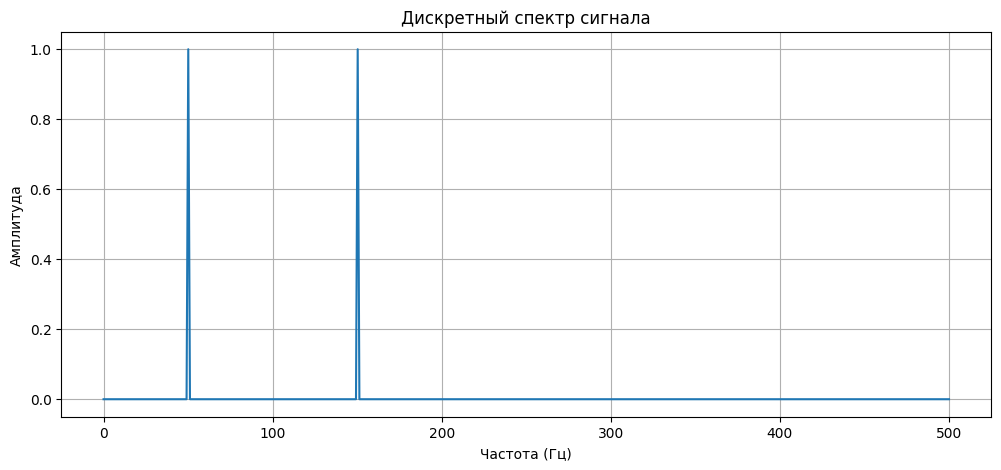

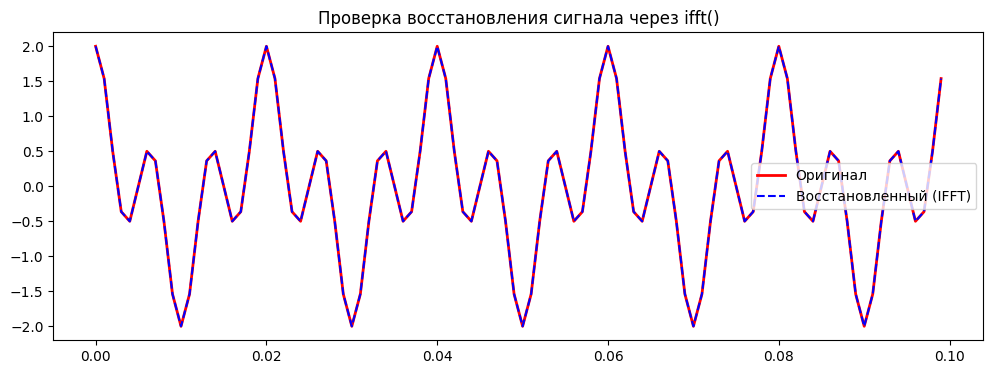

In [21]:
# Параметры Сигнала 
fs = 1000
T = 1.0
t = np.linspace(0, T, int(T * fs), endpoint=False)

x = np.cos(2 * np.pi * 50 * t) + np.cos(2 * np.pi * 150 * t)

print("Время выполнения DFT_slow:")
%timeit DFT_slow(x)

print("Время выполнения стандартного fft():")
%timeit fft(x)

# Спектр

N = len(x)
xf = np.linspace(0.0, fs/2, N//2)

yf_slow = DFT_slow(x)
yf_fast = fft(x)

plt.figure(figsize=(12,5))
plt.plot(xf, 2.0/N * np.abs(yf_fast[:N//2]), label='Спектр сигналов 50 и 150 Гц')
plt.title('Дискретный спектр сигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid()
plt.show()

# --- 4. Обратное преобразование (Пункт 1б) ---
x_reconstructed = ifft(yf_fast).real # Восстанавливаем сигнал

plt.figure(figsize=(12, 4))
plt.plot(t[:100], x[:100], 'r', label='Оригинал', lw=2)
plt.plot(t[:100], x_reconstructed[:100], 'b--', label='Восстановленный (IFFT)')
plt.title('Проверка восстановления сигнала через ifft()')
plt.legend()
plt.show()


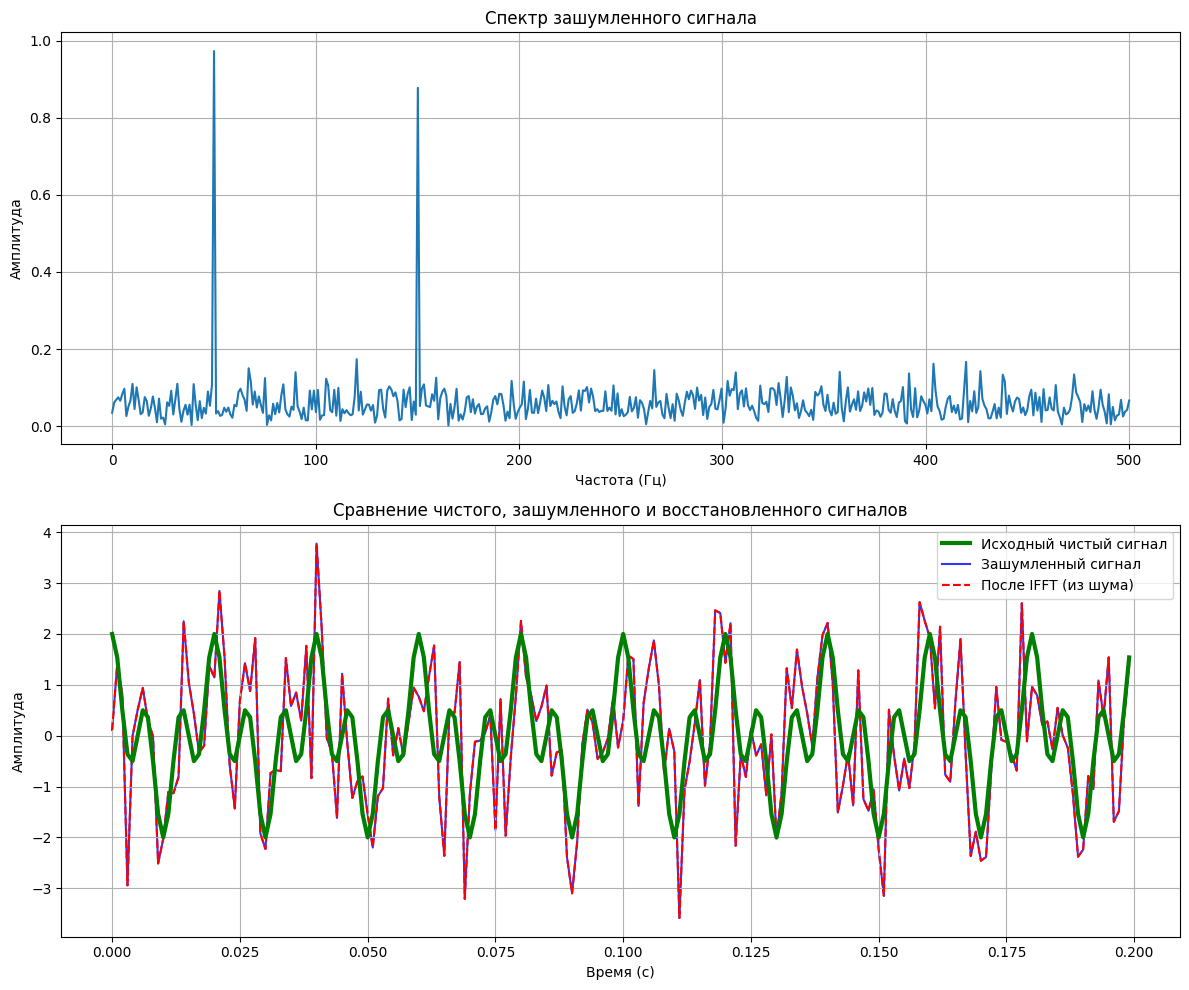

In [33]:
noise = np.random.normal(0, 1.0, x.shape)
x_noisy = x + noise

yf_noisy = fft(x_noisy)

x_recovered_noise = ifft(yf_noisy).real

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.plot(xf, 2.0/N * np.abs(yf_noisy[:N//2]))
ax1.set_title('Спектр зашумленного сигнала')
ax1.set_xlabel('Частота (Гц)')
ax1.set_ylabel('Амплитуда')
ax1.grid()

ax2.plot(t[:200], x[:200], color='green', label='Исходный чистый сигнал', lw=3, zorder=3)

ax2.plot(t[:200], x_noisy[:200], alpha=0.8, color='blue', label='Зашумленный сигнал', zorder=1)

ax2.plot(t[:200], x_recovered_noise[:200], color='red', linestyle='--', label='После IFFT (из шума)', zorder=2)

ax2.set_title('Сравнение чистого, зашумленного и восстановленного сигналов')
ax2.set_xlabel('Время (с)')
ax2.set_ylabel('Амплитуда')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

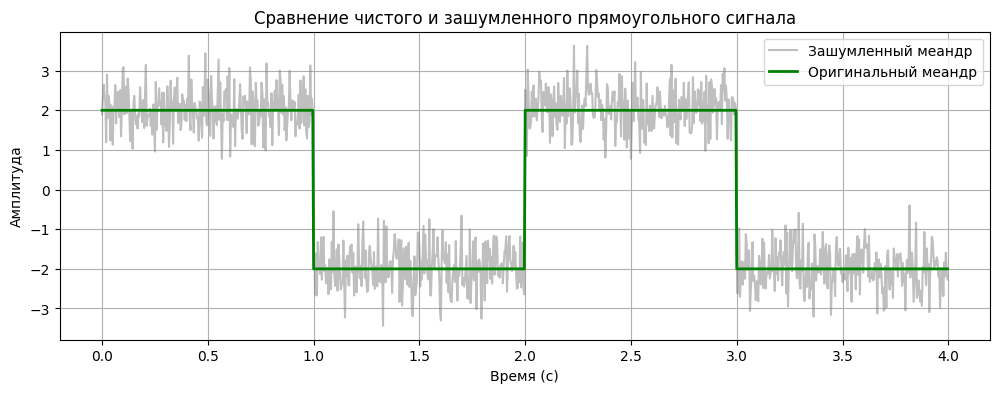

Разница между методами (FFT vs DFT_slow) для меандра: 4.4864855414112247e-10


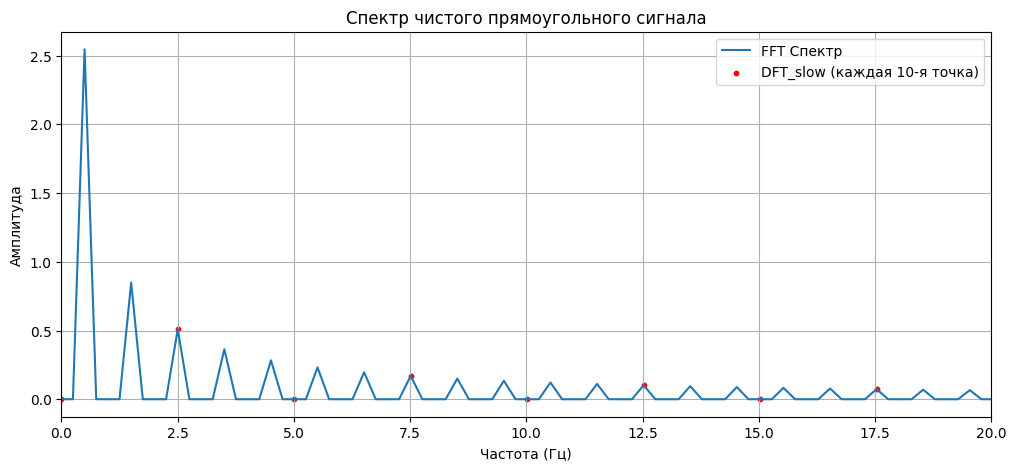

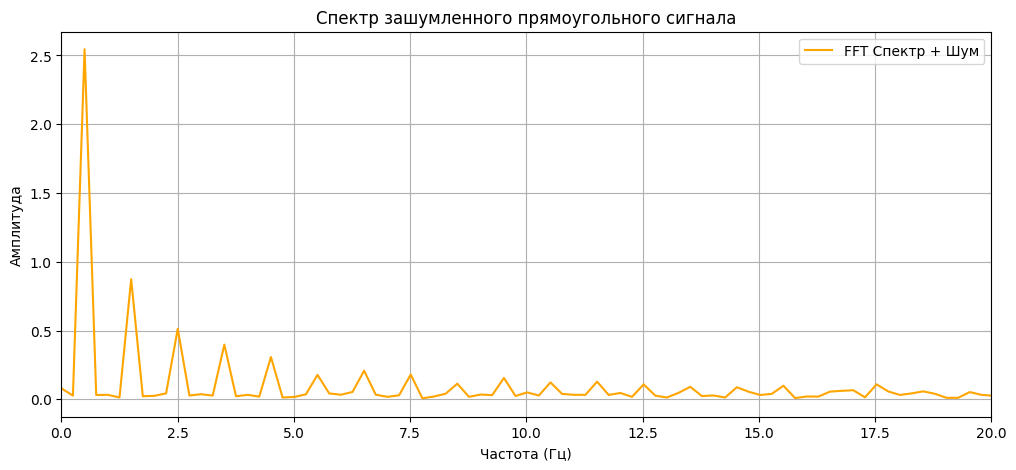

In [32]:
from scipy import signal

A_rect = 2
T_rect = 2
t_rect = np.linspace(0, 4, 1024, endpoint=False)

x_rect = A_rect * signal.square(2 * np.pi * t_rect / T_rect)

# Добавляем шум
noise_rect = np.random.normal(0, 0.5, x_rect.shape)
x_rect_noisy = x_rect + noise_rect

plt.figure(figsize=(12, 4))
plt.plot(t_rect, x_rect_noisy, color='gray', alpha=0.5, label='Зашумленный меандр')
plt.plot(t_rect, x_rect, color='green', lw=2, label='Оригинальный меандр')
plt.title('Сравнение чистого и зашумленного прямоугольного сигнала')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid()
plt.show()

yf_rect_fast = fft(x_rect)
yf_rect_slow = DFT_slow(x_rect)
N_rect = len(x_rect)
fs_rect = N_rect / 4 
xf_rect = np.linspace(0.0, fs_rect/2, N_rect//2)

print(f"Разница между методами (FFT vs DFT_slow) для меандра: {np.max(np.abs(yf_rect_fast - yf_rect_slow))}")

plt.figure(figsize=(12, 5))
plt.plot(xf_rect, 2.0/N_rect * np.abs(yf_rect_fast[:N_rect//2]), label='FFT Спектр') 
plt.scatter(xf_rect[::10], (2.0/N_rect * np.abs(yf_rect_slow[:N_rect//2]))[::10], 
            color='red', s=10, label='DFT_slow (каждая 10-я точка)')

plt.title('Спектр чистого прямоугольного сигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.legend()
plt.grid()
plt.show()

yf_rect_noisy = fft(x_rect_noisy)

plt.figure(figsize=(12, 5))
plt.plot(xf_rect, 2.0/N_rect * np.abs(yf_rect_noisy[:N_rect//2]), color='orange', label='FFT Спектр + Шум')
plt.title('Спектр зашумленного прямоугольного сигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 20)
plt.legend()
plt.grid()
plt.show()

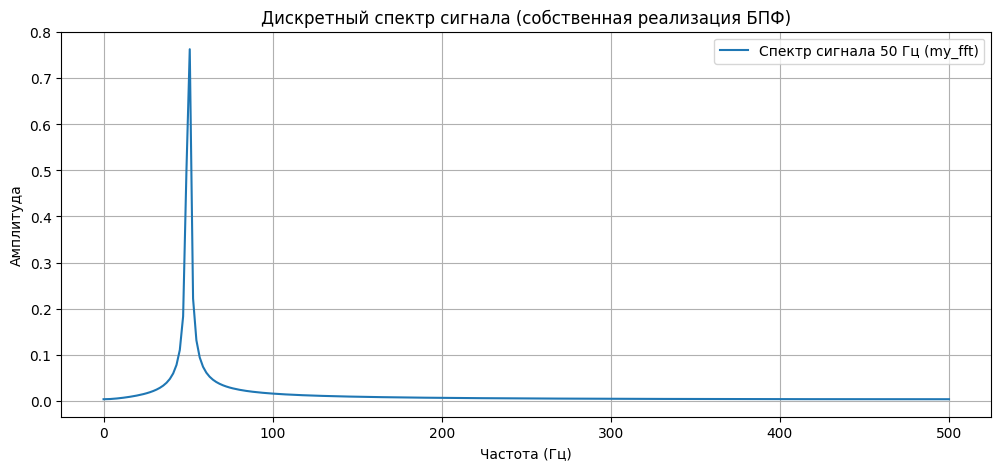

Максимальное расхождение с библиотечным FFT: 1.2079226507921703e-13

Время выполнения моего БПФ (my_fft):
6.35 ms ± 557 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

Время выполнения библиотечного fft():
8.49 μs ± 61.5 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [24]:
def my_fft(x):
    """
    Рекурсивная реализация БПФ по основанию 2.
    """
    x = np.asarray(x, dtype=complex)
    N = x.shape[0]
    
    if N <= 1:
        return x
    
    # 1. Разделяем на четные и нечетные
    even = my_fft(x[0::2])
    odd =  my_fft(x[1::2])
    
    # 2. Вычисляем поворотные коэффициенты
    T = np.exp(-2j * np.pi * np.arange(N) / N)
    
    # 3. Объединяем результаты
    return np.concatenate([even + T[:N//2] * odd,
                           even + T[N//2:] * odd])

x_test = np.cos(2 * np.pi * 50 * t)
x_test_2n = x_test[:512] 
N_test = len(x_test_2n)


# Расчет спектра нашим методом и стандартным для сравнения
yf_custom = my_fft(x_test_2n)
yf_std = fft(x_test_2n)

xf_test = np.linspace(0.0, fs/2, N_test//2)

plt.figure(figsize=(12, 5))
plt.plot(xf_test, 2.0/N_test * np.abs(yf_custom[:N_test//2]), label='Спектр сигнала 50 Гц (my_fft)')
plt.title('Дискретный спектр сигнала (собственная реализация БПФ)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid()
plt.legend()
plt.show()

print(f"Максимальное расхождение с библиотечным FFT: {np.max(np.abs(yf_custom - yf_std))}")

print("\nВремя выполнения моего БПФ (my_fft):")
%timeit my_fft(x_test_2n)

print("\nВремя выполнения библиотечного fft():")
%timeit fft(x_test_2n)